In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import pickle
from pathlib import Path

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential, save_model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [10]:
class RenewableEnergyPredictor:
    def __init__(self, target_variable='Solar', lookback=24):
        """
        Initialize the predictor with target variable and lookback period.

        Args:
            target_variable (str): Either 'Solar' or 'Wind Onshore'
            lookback (int): Number of previous time steps to use for prediction
        """
        self.target_variable = target_variable
        self.lookback = lookback
        self.feature_scaler = StandardScaler()
        self.target_scaler = MinMaxScaler()
        self.model = None
        self.history = None
        self.metrics = {}

        # Define features (excluding target-related features when not the target)
        self.base_features = [
            'temp', 'rhum', 'prcp', 'wspd', 'pres',
            'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos',
            'month_sin', 'month_cos'
        ]

        # Define country and season dummies
        self.dummy_features = [
            'country_Italy', 'country_Spain', 'season_2', 'season_3', 'season_4'
        ]

    def load_data(self, url):
        """Load and preprocess the data from the given URL."""
        self.df = pd.read_csv(url)
        self.df['time'] = pd.to_datetime(self.df['time'])
        self.df = self.df.sort_values('time').reset_index(drop=True)
        return self.df

    def prepare_features(self):
        """Prepare features based on the target variable."""
        # Start with base features
        features = self.base_features.copy()

        # Add lag features specific to the target
        target_lag_features = [f'{self.target_variable}_lag_1',
                              f'{self.target_variable}_lag_24',
                              f'{self.target_variable}_rolling_24h_mean']
        features.extend(target_lag_features)

        # Add dummy features
        features.extend(self.dummy_features)

        # Handle missing values
        self.df[features] = self.df[features].ffill().bfill()

        self.X = self.df[features].values
        self.y = self.df[self.target_variable].values

        return self.X, self.y

    def split_data(self, test_size=0.2, time_based=True):
        """Split data into training and test sets."""
        if time_based:
            split_idx = int(len(self.X) * (1 - test_size))
            self.X_train, self.X_test = self.X[:split_idx], self.X[split_idx:]
            self.y_train, self.y_test = self.y[:split_idx], self.y[split_idx:]
        else:
            self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
                self.X, self.y, test_size=test_size, shuffle=False
            )
        return self.X_train, self.X_test, self.y_train, self.y_test

    def scale_data(self):
        """Scale features and target."""
        # Scale features
        self.X_train = self.feature_scaler.fit_transform(self.X_train)
        self.X_test = self.feature_scaler.transform(self.X_test)

        # Scale target
        self.y_train_scaled = self.target_scaler.fit_transform(
            self.y_train.reshape(-1, 1)).flatten()
        self.y_test_scaled = self.target_scaler.transform(
            self.y_test.reshape(-1, 1)).flatten()

        return self.X_train, self.X_test, self.y_train_scaled, self.y_test_scaled

    def create_sequences(self, X, y):
        """Create sequences for LSTM input."""
        Xs, ys = [], []
        for i in range(self.lookback, len(X)):
            Xs.append(X[i-self.lookback:i])
            ys.append(y[i])
        return np.array(Xs), np.array(ys)

    def prepare_sequences(self):
        """Prepare training and test sequences."""
        self.X_train_seq, self.y_train_seq = self.create_sequences(
            self.X_train, self.y_train_scaled)
        self.X_test_seq, self.y_test_seq = self.create_sequences(
            self.X_test, self.y_test_scaled)
        return self.X_train_seq, self.y_train_seq, self.X_test_seq, self.y_test_seq

    def build_model(self):
        """Build and compile the LSTM model."""
        input_shape = (self.lookback, self.X_train.shape[1])
        self.model = Sequential([
            Input(shape=input_shape),
            LSTM(64, return_sequences=True),
            Dropout(0.2),
            LSTM(32),
            Dropout(0.2),
            Dense(1)
        ])
        self.model.compile(optimizer='adam', loss='mse', metrics=['mae'])
        return self.model

    def train_model(self, epochs=50, batch_size=64, validation_split=0.2):
        """Train the model."""
        self.history = self.model.fit(
            self.X_train_seq,
            self.y_train_seq,
            epochs=epochs,
            batch_size=batch_size,
            validation_split=validation_split,
            verbose=1
        )
        return self.history

    def evaluate_model(self):
        """Evaluate the model on test data."""
        self.y_pred_scaled = self.model.predict(self.X_test_seq)
        self.y_pred = self.target_scaler.inverse_transform(
            self.y_pred_scaled).flatten()

        # Calculate metrics
        self.metrics = {
            'RMSE': np.sqrt(mean_squared_error(self.y_test_scaled[self.lookback:], self.y_pred_scaled)),
            'MAE': mean_absolute_error(self.y_test_scaled[self.lookback:], self.y_pred_scaled),
            'R2': r2_score(self.y_test_scaled[self.lookback:], self.y_pred_scaled)
        }

        return self.metrics

    def plot_results(self, n_samples=100):
        """Plot actual vs predicted values."""
        plt.figure(figsize=(15, 6))
        plt.plot(self.y_test_scaled[:n_samples], label='Actual')
        plt.plot(self.y_pred_scaled[:n_samples], label='Predicted')
        plt.title(f"{self.target_variable} Production Forecast")
        plt.xlabel("Time Steps")
        plt.ylabel(f"{self.target_variable} Output (scaled)")
        plt.legend()
        plt.show()

        # Plot training history
        plt.figure(figsize=(12, 6))
        plt.plot(self.history.history['loss'], label='Train Loss')
        plt.plot(self.history.history['val_loss'], label='Validation Loss')
        plt.title("Training/Validation Loss Curve")
        plt.xlabel("Epochs")
        plt.ylabel("MSE Loss")
        plt.legend()
        plt.show()

    def save_model(self, model_dir="models"):
        """Save model and scalers."""
        Path(model_dir).mkdir(exist_ok=True)

        # Save model in both formats
        save_model(self.model, f"{model_dir}/{self.target_variable.lower()}_lstm_model.keras")
        save_model(self.model, f"{model_dir}/{self.target_variable.lower()}_lstm_model.h5")

        # Save scalers
        scalers = {
            "feature_scaler": self.feature_scaler,
            "target_scaler": self.target_scaler
        }

        with open(f"{model_dir}/{self.target_variable.lower()}_scalers.pkl", "wb") as f:
            pickle.dump(scalers, f)

        # Save metrics
        metrics_df = pd.DataFrame({
            'Model': ['LSTM'],
            'Target': [self.target_variable],
            'RMSE': [self.metrics['RMSE']],
            'MAE': [self.metrics['MAE']],
            'R2': [self.metrics['R2']]
        })

        metrics_df.to_csv(f"{model_dir}/{self.target_variable.lower()}_metrics.csv", index=False)

        print(f"Model and artifacts saved in {model_dir}/ directory")

In [11]:
if __name__ == "__main__":
    url = "https://raw.githubusercontent.com/TiffanyPanchum/Renewable-Energy-Prediction/refs/heads/main/data/processed/Feature_Engineering%20_Dataset/feature_engineered_data.csv"

    # Run for Wind Onshore
    wind_predictor = RenewableEnergyPredictor(target_variable='Wind Onshore')

    # Load and prepare data
    wind_predictor.load_data(url)
    wind_predictor.prepare_features()
    wind_predictor.split_data()
    wind_predictor.scale_data()
    wind_predictor.prepare_sequences()

    # Build and train model
    wind_predictor.build_model()
    wind_predictor.train_model()

    # Run for Solar
    solar_predictor = RenewableEnergyPredictor(target_variable='Solar')

    # Load and prepare data
    solar_predictor.load_data(url)
    solar_predictor.prepare_features()
    solar_predictor.split_data()
    solar_predictor.scale_data()
    solar_predictor.prepare_sequences()

    # Build and train model
    solar_predictor.build_model()
    solar_predictor.train_model()

Epoch 1/50
1772/1772 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 0.0166 - mae: 0.0971 - val_loss: 0.0178 - val_mae: 0.0979
Epoch 2/50
1772/1772 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 0.0097 - mae: 0.0716 - val_loss: 0.0161 - val_mae: 0.0925
Epoch 3/50
1772/1772 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 0.0079 - mae: 0.0633 - val_loss: 0.0151 - val_mae: 0.0882
Epoch 4/50
1772/1772 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 0.0062 - mae: 0.0551 - val_loss: 0.0147 - val_mae: 0.0859
Epoch 5/50
1772/1772 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 0.0055 - mae: 0.0508 - val_loss: 0.0143 - val_mae: 0.0838
Epoch 6/50
1772/1772 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - loss: 0.0050 - mae: 0.0477 - val_loss: 0.0140 - val_mae: 0.0823
Epoch 7/50
1772/1772 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 0.0046 - mae: 0.0451 - val_loss: 0.0136 - val_mae: 0.0808
Epoch 8/50
1772/1772 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 0.0044 - mae: 0.0436 - val_loss: 0.0137 - val_mae: 0.0796
Epoch 9/50
1772/1772 ━━━━━━━━━━━

1107/1107 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Test Metrics for Wind Onshore:
RMSE: 0.12
MAE: 0.07
R²: 0.48


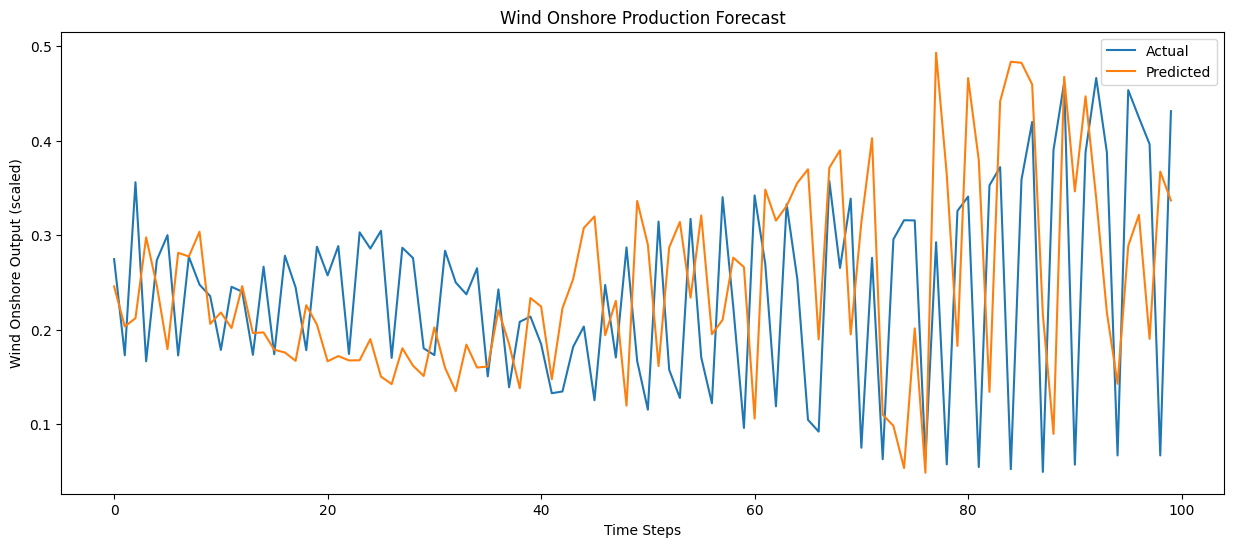

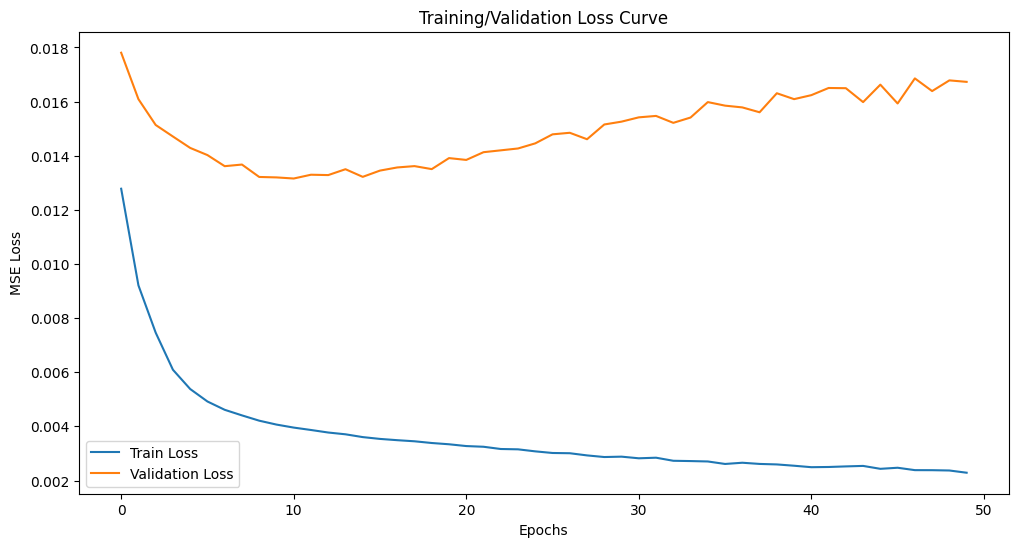

Model and artifacts saved in models/ directory
1107/1107 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
Test Metrics for Solar:
RMSE: 0.15
MAE: 0.09
R²: 0.77


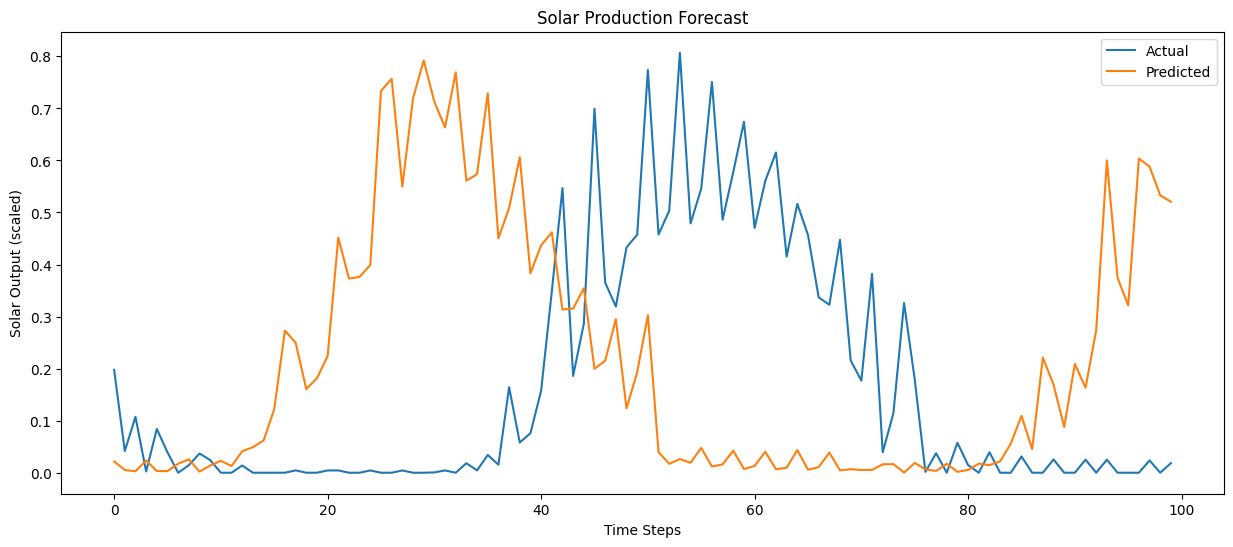

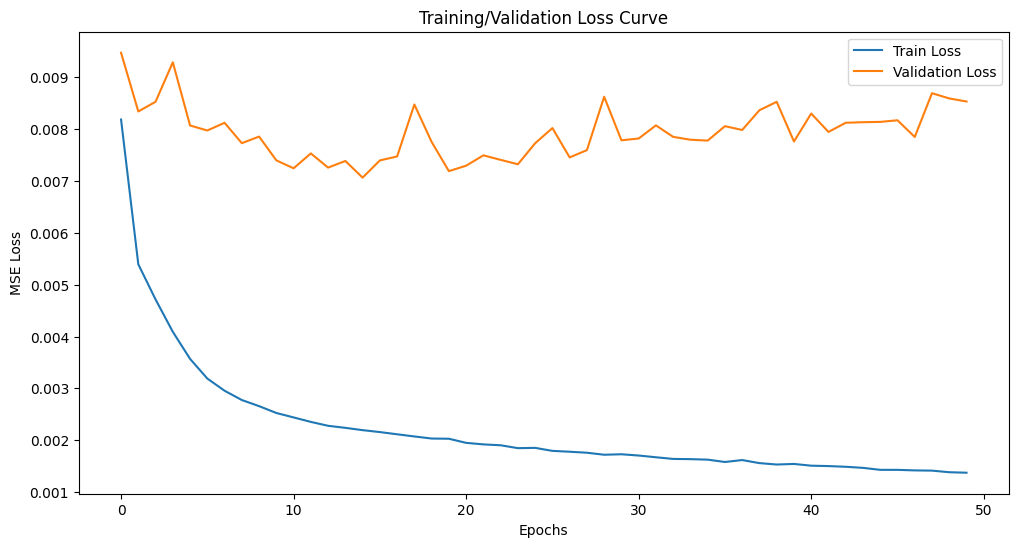

Model and artifacts saved in models/ directory


In [12]:
    # Evaluate and show results for Wind Offshore
    metrics = wind_predictor.evaluate_model()
    print(f"Test Metrics for {wind_predictor.target_variable}:")
    print(f"RMSE: {metrics['RMSE']:.2f}")
    print(f"MAE: {metrics['MAE']:.2f}")
    print(f"R²: {metrics['R2']:.2f}")

    wind_predictor.plot_results()
    wind_predictor.save_model()


    # Evaluate and show results for Solar
    metrics = solar_predictor.evaluate_model()
    print(f"Test Metrics for {solar_predictor.target_variable}:")
    print(f"RMSE: {metrics['RMSE']:.2f}")
    print(f"MAE: {metrics['MAE']:.2f}")
    print(f"R²: {metrics['R2']:.2f}")

    solar_predictor.plot_results()
    solar_predictor.save_model()